# Sinhala Document OCR — Local Pipeline (Windows + Jupyter)

This notebook runs the **same baseline pipeline** as `notebooks/colab_pipeline.ipynb`, but on your laptop:

1. Setup paths (no git clone)
2. Install Python dependencies
3. Verify Sinhala fonts on Windows
4. Load `configs/local.yaml`
5. Generate synthetic training lines into `data/synthetic/`
6. Train the CRNN recognizer
7. Evaluate CER/WER on the test split
8. Run OCR on an uploaded document in `data/uploads/`

**Tip for MSc experiments:** change `NUM_SAMPLES` and `EPOCHS` in Section 4, then re-run from Section 5 onward.


## 1. Setup — project root and imports

The notebook lives in `notebooks/`, so the repository root is the parent directory. We add it to `sys.path` so `import src...` works.


In [1]:
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "local_pipeline.ipynb").exists():
    REPO_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "notebooks" / "local_pipeline.ipynb").exists():
    REPO_ROOT = NOTEBOOK_DIR
else:
    REPO_ROOT = NOTEBOOK_DIR.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("cwd:", REPO_ROOT)
for name in ("src", "configs", "requirements.txt"):
    p = REPO_ROOT / name
    print(f"  {name}: {'OK' if p.exists() else 'MISSING'}", p)


cwd: C:\Users\ASUS TUF\Projects\sinhala-document-ocr
  src: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\src
  configs: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs
  requirements.txt: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\requirements.txt


## 2. Install dependencies

Run once per environment. Key packages: **PyTorch**, **OpenCV**, **Albumentations**, **PyYAML**, **matplotlib**, **Jupyter**.


In [2]:
%pip install -q -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


## 3. Font setup (Windows)

Synthetic lines are rendered with a TrueType font. On Windows, **Nirmala UI** (`Nirmala.ttc`) usually supports Sinhala. **Iskoola Pota** (`iskpota.ttf`) is used when present.


In [3]:
from pathlib import Path

FONT_CANDIDATES = [
    Path(r"C:/Windows/Fonts/Nirmala.ttc"),
    Path(r"C:/Windows/Fonts/iskpota.ttf"),
    REPO_ROOT / "fonts" / "NotoSansSinhala-Regular.ttf",
]

FONT_PATHS = [str(p) for p in FONT_CANDIDATES if p.is_file()]
if not FONT_PATHS:
    print(
        "WARNING: No Sinhala font found. Install Nirmala UI / Iskoola Pota or place Noto Sans Sinhala under fonts/."
    )
else:
    print("Using fonts:")
    for fp in FONT_PATHS:
        print(" ", fp)


Using fonts:
  C:\Windows\Fonts\Nirmala.ttc


## 4. Load configuration

We load `configs/local.yaml` (laptop-friendly defaults). You can override sample count and training epochs here.


In [4]:
import torch
from src.utils.common import load_config, get_logger
from src.utils.display import configure_display_utf8, setup_matplotlib_sinhala

configure_display_utf8()
logger = get_logger("local_pipeline")

CONFIG_PATH = str(REPO_ROOT / "configs" / "local.yaml")
cfg = load_config(CONFIG_PATH)

if FONT_PATHS:
    cfg["synthetic"]["fonts"] = FONT_PATHS

PRIMARY_FONT = FONT_PATHS[0] if FONT_PATHS else None
MPL_FONT = setup_matplotlib_sinhala(PRIMARY_FONT)
if MPL_FONT:
    print("Matplotlib Sinhala font:", MPL_FONT)
else:
    print("WARNING: matplotlib Sinhala font not configured (see src/utils/display.py)")

# Tunables for local runs (increase for better accuracy, at the cost of time)
NUM_SAMPLES = cfg["synthetic"].get("large", {}).get("num_samples", 5000)
EPOCHS = cfg["train"]["epochs"]
BATCH_SIZE = cfg["train"]["batch_size"]
if not torch.cuda.is_available() and BATCH_SIZE > 16:
    BATCH_SIZE = 16
    print("No CUDA GPU detected — using batch_size =", BATCH_SIZE, "(CPU training will be slow)")

OUT_DIR = cfg["paths"]["synthetic_dir"]
UPLOADS_DIR = cfg["paths"].get("uploads_dir", "data/uploads")
DEBUG_DIR = cfg["paths"].get("debug_dir", "data/debug")

print("config:", CONFIG_PATH)
print("NUM_SAMPLES:", NUM_SAMPLES)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)
print("synthetic output:", OUT_DIR)
print("uploads:", UPLOADS_DIR)


config: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs\local.yaml
NUM_SAMPLES: 5000
EPOCHS: 15
BATCH_SIZE: 32
synthetic output: data/synthetic
uploads: data/uploads


## 5. Generate synthetic data

Calls `src.data.synthetic_generator.generate` and writes train/val/test splits plus `*_labels.txt` under `data/synthetic/`.


In [5]:
from src.data.synthetic_generator import generate, load_word_lists

words = load_word_lists([cfg["paths"]["word_list"], cfg["paths"].get("form_vocab")], warn=logger.warning)
print("Vocabulary entries:", len(words))

counts = generate(
    out_dir=OUT_DIR,
    num_samples=NUM_SAMPLES,
    font_paths=cfg["synthetic"]["fonts"],
    font_sizes=cfg["synthetic"]["font_sizes"],
    words=words,
    min_words=cfg["synthetic"]["min_words"],
    max_words=cfg["synthetic"]["max_words"],
    augment=cfg["synthetic"]["augment"],
    split=cfg["synthetic"]["split"],
    seed=cfg["project"]["seed"],
    logger=logger,
    numeric_ratio=cfg["synthetic"]["numeric_ratio"],
    mixed_ratio=cfg["synthetic"]["mixed_ratio"],
)
print("Split counts:", counts)


23:27:56 | INFO    | local_pipeline | [fonts] using 1 font(s); 485 vocab entries; 5000 samples


Vocabulary entries: 485


render: 100%|██████████████████████████████████████████████████████████████████████| 5000/5000 [02:21<00:00, 35.37it/s]
23:30:18 | INFO    | local_pipeline | [split] train: 3500 samples
23:30:18 | INFO    | local_pipeline | [split] val: 750 samples
23:30:18 | INFO    | local_pipeline | [split] test: 750 samples
23:30:18 | INFO    | local_pipeline | [done] wrote 5000 images to data/synthetic\images


Split counts: {'train': 3500, 'val': 750, 'test': 750}


### Preview a few generated lines

OCR training and metrics use Unicode labels on disk; **this plot is only for visual verification**. With `setup_matplotlib_sinhala()` (Section 4), Sinhala ground-truth text should render in the titles below.


C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_32364\3302181628.py:15: UserWarning: Glyph 3503 (\N{SINHALA LETTER ALPAPRAANA DAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_32364\3302181628.py:15: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_32364\3302181628.py:15: UserWarning: Glyph 3513 (\N{SINHALA LETTER AMBA BAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_32364\3302181628.py:15: UserWarning: Glyph 3540 (\N{SINHALA VOWEL SIGN KETTI PAA-PILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_32364\3302181628.py:15: UserWarning: Glyph 3517 (\N{SINHALA LETTER DANTAJA LAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_32364\3302181628.py:15: UserWarning: Gly

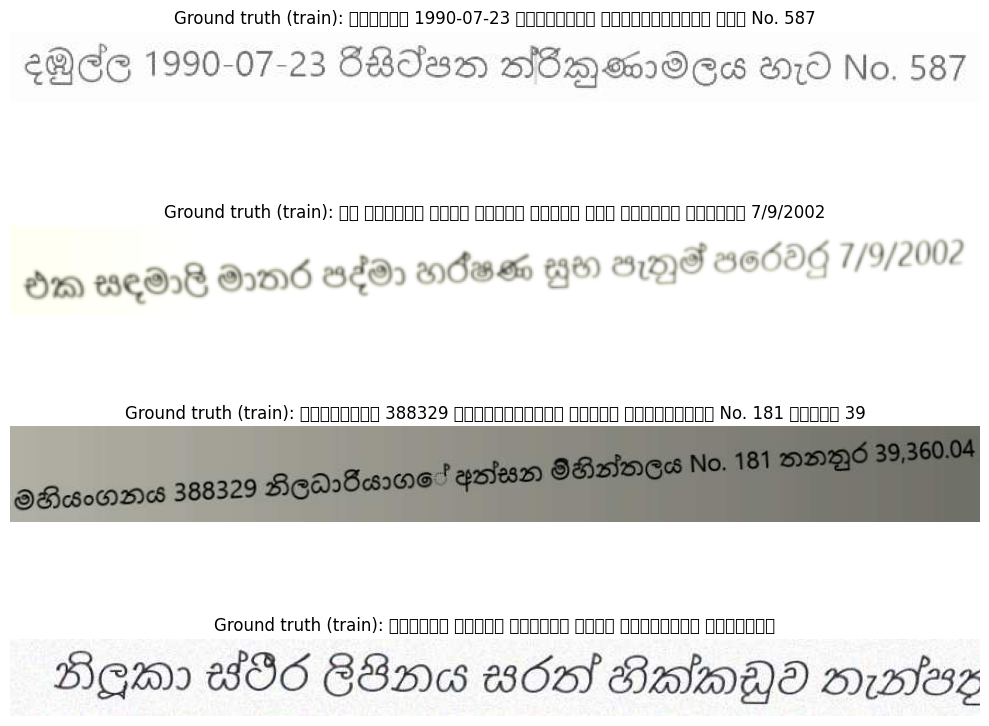

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
from src.data.dataset import read_labels

rows = read_labels(str(REPO_ROOT / OUT_DIR / "train_labels.txt"))
n = min(4, len(rows))
fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n))
if n == 1:
    axes = [axes]
for ax, (rel, text) in zip(axes, rows[:n]):
    img = Image.open(REPO_ROOT / OUT_DIR / rel)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Ground truth (train): {text[:60]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Train the CRNN baseline

Uses GPU when `torch.cuda.is_available()`, otherwise CPU (expect long runtimes). Checkpoints are saved under `models/`.


In [11]:
import subprocess
import sys

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Training device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: CPU training is slow — consider fewer samples/epochs or a CUDA machine.")

cmd = [
    sys.executable,
    "-m",
    "src.recognition.train",
    "--config",
    CONFIG_PATH,
    f"paths.synthetic_dir={OUT_DIR}",
    f"train.epochs={EPOCHS}",
    f"train.batch_size={BATCH_SIZE}",
    f"train.device={DEVICE}",
]
print(" ".join(cmd))
result = subprocess.run(cmd, cwd=str(REPO_ROOT))
if result.returncode != 0:
    raise SystemExit(result.returncode)


Training device: cuda
C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\python.exe -m src.recognition.train --config C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs\local.yaml paths.synthetic_dir=data/synthetic train.epochs=15 train.batch_size=32 train.device=cuda


KeyboardInterrupt: 

## 7. Evaluate on the test set

Reports **Character Error Rate (CER)** and **Word Error Rate (WER)** on `data/synthetic/test_labels.txt`.


In [ ]:
from src.charset import Charset
from src.data.dataset import build_dataloader
from src.recognition.model import build_crnn
from src.evaluation.metrics import evaluate_model
from src.utils.common import load_checkpoint, get_device

charset = Charset.load(str(REPO_ROOT / cfg["paths"]["charset_path"]))
device = get_device(DEVICE)
model = build_crnn(charset.num_classes, cfg.get("model"), in_channels=cfg["image"]["channels"]).to(device)
load_checkpoint(str(REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_best.pth"), model, map_location=str(device))
model.eval()

test_loader = build_dataloader(
    str(REPO_ROOT / OUT_DIR / "test_labels.txt"),
    charset,
    batch_size=BATCH_SIZE,
    height=cfg["image"]["height"],
    max_width=cfg["image"]["max_width"],
    channels=cfg["image"]["channels"],
    shuffle=False,
    num_workers=cfg["train"]["num_workers"],
)

report = evaluate_model(model, test_loader, charset, device=device, measure_cpu_time=False)
print(f"TEST  samples={report['num_samples']}  CER={report['cer']:.4f}  WER={report['wer']:.4f}")


### Qualitative test predictions (ground truth vs model)

Sinhala strings below use the matplotlib font from Section 4.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

test_rows = read_labels(str(REPO_ROOT / OUT_DIR / "test_labels.txt"))
n = min(5, len(test_rows))
fig, axes = plt.subplots(n, 1, figsize=(10, 1.8 * n))
if n == 1:
    axes = [axes]
for ax, (rel, _), sample in zip(axes, test_rows[:n], report["per_sample"][:n]):
    ax.imshow(Image.open(REPO_ROOT / OUT_DIR / rel), cmap="gray")
    ax.set_title(
        f"GT: {sample['ref'][:40]}\nPRED: {sample['hyp'][:40]} (CER={sample['cer']:.2f})",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Upload test — document OCR

Place a photo or scan in `data/uploads/`, or set `LOCAL_UPLOAD_PATH` below. The pipeline uses grayscale detection, optional invert, and **height 48** recognition (same as training).


In [ ]:
import glob

LOCAL_UPLOAD_PATH = ""  # e.g. r"C:\Users\You\Pictures\form.jpg"

INVERT_IF_DARK_BG = True
SKIP_DOCUMENT_BINARIZE = True
USE_WHOLE_IMAGE_IF_ONE_LINE = True

upload_root = REPO_ROOT / UPLOADS_DIR
upload_root.mkdir(parents=True, exist_ok=True)

UPLOADED_IMAGE_PATH = LOCAL_UPLOAD_PATH.strip()
if not UPLOADED_IMAGE_PATH:
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
        hits = sorted(upload_root.glob(ext))
        if hits:
            UPLOADED_IMAGE_PATH = str(hits[-1])
            break

if not UPLOADED_IMAGE_PATH or not Path(UPLOADED_IMAGE_PATH).is_file():
    print(
        "Set LOCAL_UPLOAD_PATH or copy an image into",
        upload_root,
        "then re-run this cell.",
    )
else:
    print("Using:", UPLOADED_IMAGE_PATH)


In [ ]:
import cv2
import matplotlib.pyplot as plt
import torch

from src.charset import Charset
from src.detection.text_detection import OpenCVLineDetector, crop_lines, draw_boxes
from src.preprocessing.preprocess import preprocess_document
from src.recognition.inference import inference_options_from_config, prepared_line_for_display
from src.recognition.model import build_crnn
from src.recognition.predict import predict_line_array
from src.utils.common import get_device, load_checkpoint

if not UPLOADED_IMAGE_PATH or not Path(UPLOADED_IMAGE_PATH).is_file():
    raise RuntimeError("Configure an upload path in the cell above.")

INF_OPTS = inference_options_from_config(cfg)
RECOGNITION_HEIGHT = INF_OPTS["height"]
CHECKPOINT_PATH = REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_best.pth"
CHARSET_PATH = REPO_ROOT / cfg["paths"]["charset_path"]

device = get_device(DEVICE)
charset = Charset.load(str(CHARSET_PATH))
model = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS["channels"]).to(device)
load_checkpoint(str(CHECKPOINT_PATH), model, map_location=str(device))
model.eval()

page_bgr = cv2.imread(UPLOADED_IMAGE_PATH, cv2.IMREAD_COLOR)
page_gray = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2GRAY)
page_for_det = page_gray if SKIP_DOCUMENT_BINARIZE else preprocess_document(page_bgr)

skip_detection = False
if USE_WHOLE_IMAGE_IF_ONE_LINE:
    ph, pw = page_gray.shape[:2]
    if pw >= 4 * ph or ph <= 3 * max(int(cfg["detection"]["min_line_height"]), 1):
        skip_detection = True
        print("[info] Single-line heuristic: using full image.")

if skip_detection:
    boxes = [(0, 0, page_gray.shape[1], page_gray.shape[0])]
else:
    detector = OpenCVLineDetector(
        dilate_kernel=tuple(cfg["detection"]["dilate_kernel"]),
        min_line_height=int(cfg["detection"]["min_line_height"]),
        min_line_width=int(cfg["detection"]["min_line_width"]),
    )
    boxes = detector.detect(page_for_det) or [(0, 0, page_for_det.shape[1], page_for_det.shape[0])]

line_crops = crop_lines(
    page_gray,
    boxes,
    padding_x=int(cfg["detection"].get("crop_padding_x", 10)),
    padding_y=int(cfg["detection"].get("crop_padding_y", 5)),
    min_crop_height=int(cfg["detection"].get("min_crop_height", 14)),
)

upload_predictions = []
auto_inv = INVERT_IF_DARK_BG and INF_OPTS["auto_invert"]
with torch.no_grad():
    for i, crop in enumerate(line_crops):
        text = predict_line_array(
            model,
            charset,
            crop,
            INF_OPTS["height"],
            INF_OPTS["max_width"],
            INF_OPTS["channels"],
            device,
            auto_invert=auto_inv,
            denoise=INF_OPTS["denoise"],
            min_model_width=INF_OPTS.get("min_model_width", 0),
            pad_to_height=INF_OPTS.get("pad_to_height", True),
            warn_garbage=True,
        )
        upload_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
        print(f"Line {i + 1}:", text)

print("--- Full transcription ---")
print("\n".join(p["text"] for p in upload_predictions))

n_up = len(upload_predictions)
if n_up:
    fig, axes = plt.subplots(n_up, 1, figsize=(10, 1.8 * n_up))
    if n_up == 1:
        axes = [axes]
    for ax, row in zip(axes, upload_predictions):
        ax.imshow(row["crop"], cmap="gray")
        ax.set_title(f"Line {row['line']}: {row['text'][:80]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 9. Optional — save debug outputs

Writes a JSON summary and cropped line images to `data/debug/` for your thesis appendix or error analysis.


In [ ]:
import json
from datetime import datetime, timezone

debug_root = REPO_ROOT / DEBUG_DIR
debug_root.mkdir(parents=True, exist_ok=True)
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_dir = debug_root / f"upload_{stamp}"
run_dir.mkdir(parents=True, exist_ok=True)

if upload_predictions:
    summary = {
        "source_image": UPLOADED_IMAGE_PATH,
        "lines": [{"line": p["line"], "text": p["text"]} for p in upload_predictions],
        "test_cer": globals().get("report", {}).get("cer"),
        "test_wer": globals().get("report", {}).get("wer"),
    }
    (run_dir / "predictions.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    for p in upload_predictions:
        cv2.imwrite(str(run_dir / f"line_{p['line']:02d}.png"), p["crop"])
    print("Saved debug outputs to", run_dir)
else:
    print("No predictions to save — run Section 8 first.")
